In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
data=pd.read_csv('Microsoft_Stock.csv')
data

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438
...,...,...,...,...,...,...
1506,3/25/2021 16:00:00,235.30,236.94,231.57,232.34,34061853
1507,3/26/2021 16:00:00,231.55,236.71,231.55,236.48,25479853
1508,3/29/2021 16:00:00,236.59,236.80,231.88,235.24,25227455
1509,3/30/2021 16:00:00,233.53,233.85,231.10,231.85,24792012


In [3]:
df=(data[['Date','Close']])
df=df.rename(columns={'Date':'ds','Close':'y'})
df['ds']=pd.to_datetime(df['ds'])
print(df.isnull().sum())
print(df.info())


ds    0
y     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1511 non-null   datetime64[ns]
 1   y       1511 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 23.7 KB
None


In [4]:
p_value=adfuller(df['y'])[1]
if p_value>0.05:
    print("Non-Stationary")
else:
    print("Stationary")

Non-Stationary


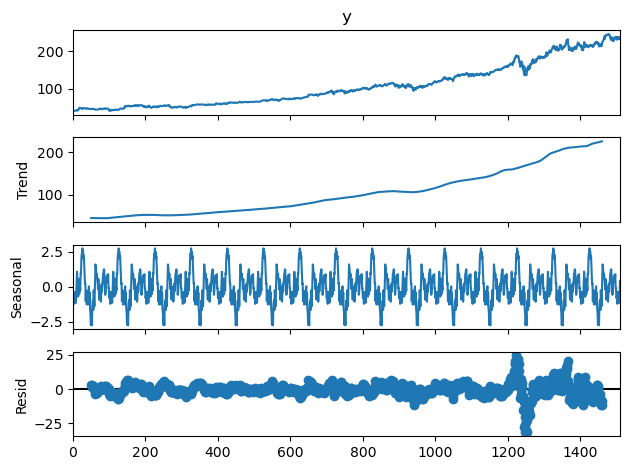

In [5]:
s_decompose=seasonal_decompose(df['y'],period=100,model='additive')
s_decompose.plot()
plt.show()

In [6]:
split=int(len(df)*0.8)
train,test=df[:split],df[split:]

In [7]:
model=Prophet()
model.fit(df)

15:37:33 - cmdstanpy - INFO - Chain [1] start processing
15:37:33 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future=model.make_future_dataframe(periods=360)


In [9]:
forecast=model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1565: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1565: RuntimeWarning: invalid value encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/op

,ds,yhat,yhat_lower,yhat_upper
1866,2022-03-22 16:00:00,303.067157,289.049750,317.940528
1867,2022-03-23 16:00:00,303.349995,288.603580,317.028472
1868,2022-03-24 16:00:00,303.573181,288.412939,318.251590
1869,2022-03-25 16:00:00,303.839928,289.523837,317.423414
1870,2022-03-26 16:00:00,227.688991,213.950723,242.354872


In [10]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-04-01 16:00:00,31.581850,32.436006,45.630947,31.581850,31.581850,7.459371,7.459371,7.459371,-12.046952,...,24.382285,24.382285,24.382285,-4.875962,-4.875962,-4.875962,0.0,0.0,0.0,39.041220
1,2015-04-02 16:00:00,31.592988,32.991495,45.624212,31.592988,31.592988,7.666371,7.666371,7.666371,-12.046952,...,24.344826,24.344826,24.344826,-4.631503,-4.631503,-4.631503,0.0,0.0,0.0,39.259359
2,2015-04-06 16:00:00,31.637540,34.013371,46.209752,31.637540,31.637540,8.598595,8.598595,8.598595,-12.046952,...,24.237859,24.237859,24.237859,-3.592311,-3.592311,-3.592311,0.0,0.0,0.0,40.236136
3,2015-04-07 16:00:00,31.648678,33.609767,46.787997,31.648678,31.648678,8.956723,8.956723,8.956723,-12.046952,...,24.332182,24.332182,24.332182,-3.328507,-3.328507,-3.328507,0.0,0.0,0.0,40.605402
4,2015-04-08 16:00:00,31.659817,34.245769,47.331666,31.659817,31.659817,9.268126,9.268126,9.268126,-12.046952,...,24.382285,24.382285,24.382285,-3.067207,-3.067207,-3.067207,0.0,0.0,0.0,40.927943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,2022-03-22 16:00:00,297.126519,289.049750,317.940528,284.620580,309.729720,5.940638,5.940638,5.940638,-12.046952,...,24.332182,24.332182,24.332182,-6.344592,-6.344592,-6.344592,0.0,0.0,0.0,303.067157
1867,2022-03-23 16:00:00,297.313007,288.603580,317.028472,284.742683,309.966148,6.036987,6.036987,6.036987,-12.046952,...,24.382285,24.382285,24.382285,-6.298346,-6.298346,-6.298346,0.0,0.0,0.0,303.349995
1868,2022-03-24 16:00:00,297.499496,288.412939,318.251590,284.864785,310.230560,6.073684,6.073684,6.073684,-12.046952,...,24.344826,24.344826,24.344826,-6.224190,-6.224190,-6.224190,0.0,0.0,0.0,303.573181
1869,2022-03-25 16:00:00,297.685985,289.523837,317.423414,284.986888,310.520181,6.153943,6.153943,6.153943,-12.046952,...,24.324200,24.324200,24.324200,-6.123305,-6.123305,-6.123305,0.0,0.0,0.0,303.839928


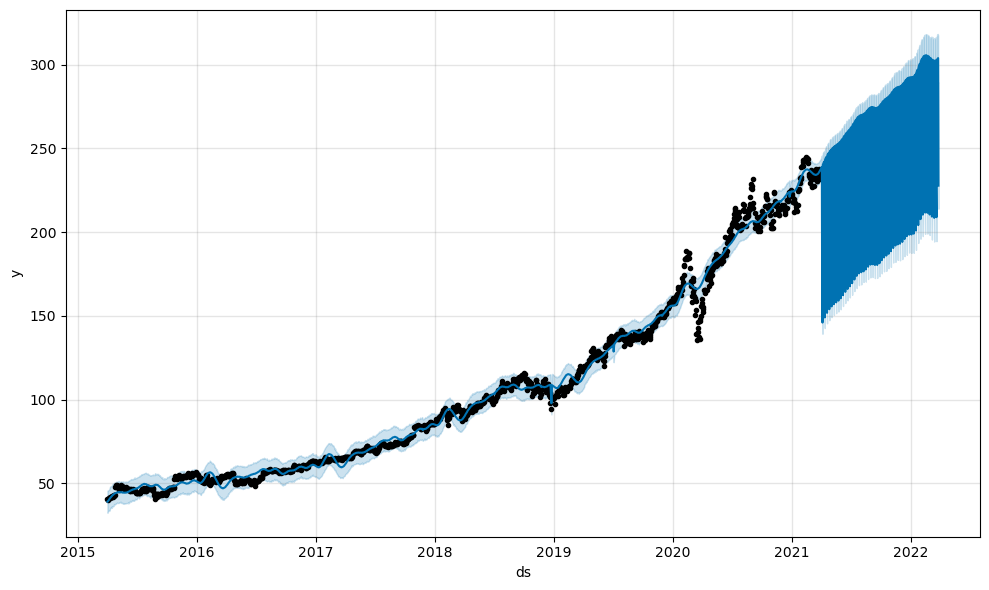

In [11]:
model.plot(forecast)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anaconda3/lib/python3.13/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/opt/anacond

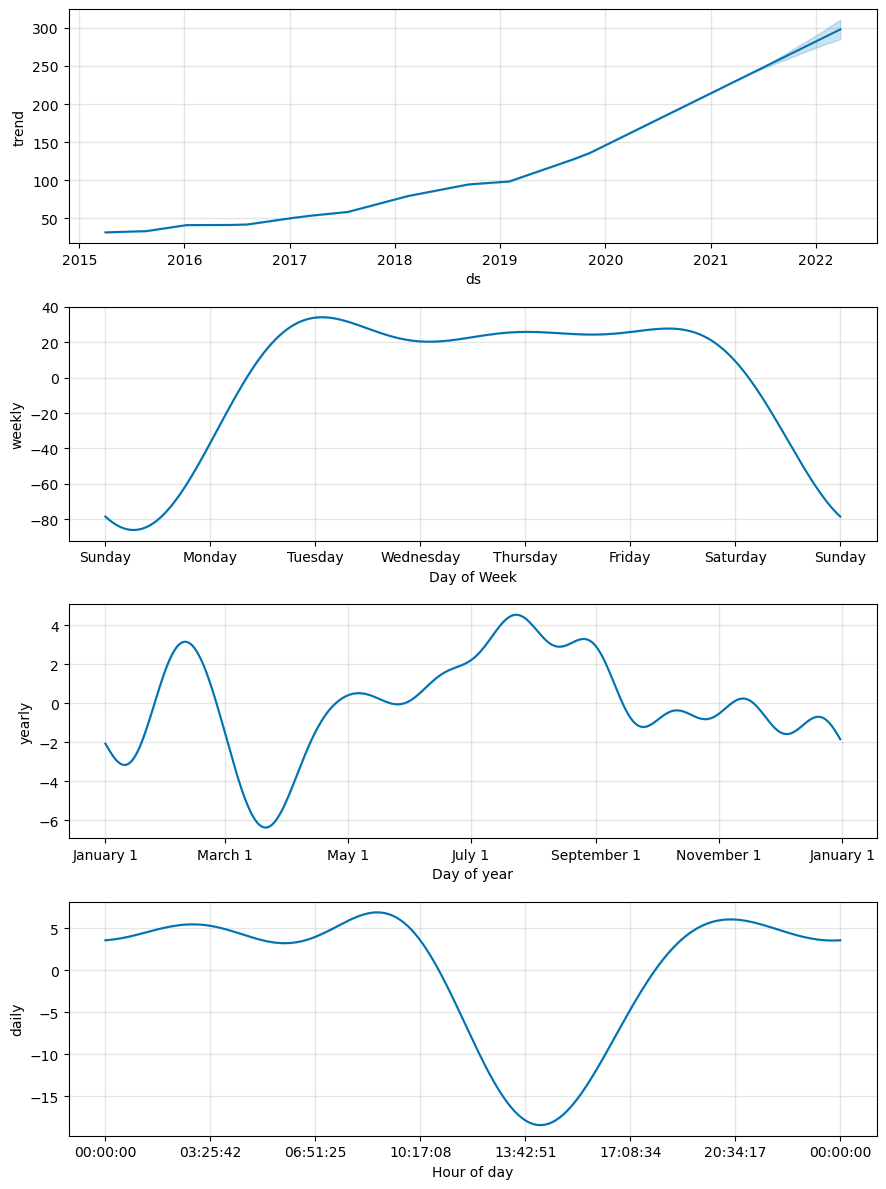

In [12]:
model.plot_components(forecast)
plt.show()